# Battery Dispatch Analysis: Why Grid Purchases Despite Available Battery Capacity

This notebook investigates why the SAM model purchases electricity from the grid even when the battery has available capacity (SOC > 60%). We'll analyze the dispatch logic and identify patterns in the energy flow data.

## Key Questions:
1. When does the system buy from grid despite available battery capacity?
2. What are the SOC thresholds for different dispatch decisions?
3. Is this conservative behavior economically justified?
4. How does time-of-day affect dispatch decisions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Load SAM Data for Analysis

We'll load the SAM optimized load profiles for multiple counties and scenarios to analyze battery dispatch patterns.

In [2]:
def load_sam_data(scenario, housing_type, county_slug, base_dir="data/loadprofiles"):
    """
    Load SAM optimized load profiles for a specific county and scenario.
    """
    file_path = os.path.join(base_dir, scenario, housing_type, county_slug, 
                            f"sam_optimized_load_profiles_{county_slug}.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None
    
    try:
        # Load with proper datetime parsing
        df = pd.read_csv(file_path, parse_dates=[0], index_col=0)
        
        # Add time-based features for analysis
        df['hour'] = df.index.hour
        df['month'] = df.index.month
        df['day_of_year'] = df.index.dayofyear
        df['season'] = df['month'].map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring', 
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
        
        # Add time-of-use categories (typical CA utility periods)
        def get_tou_period(hour):
            if 16 <= hour <= 21:  # 4-9 PM
                return 'Peak'
            elif 7 <= hour <= 15:  # 7 AM - 3 PM
                return 'Mid-Peak'
            else:  # 10 PM - 6 AM
                return 'Off-Peak'
        
        df['tou_period'] = df['hour'].apply(get_tou_period)
        
        print(f"Loaded {len(df)} hours of data for {county_slug} - {scenario}")
        print(f"Date range: {df.index.min()} to {df.index.max()}")
        print(f"Available columns: {list(df.columns)}")
        
        return df
        
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Load data for analysis
scenario = "heat_pump"  # Change this to test different scenarios
housing_type = "single-family-detached"
county = "alameda"

df = load_sam_data(scenario, housing_type, county)

if df is not None:
    # Display basic statistics
    print("\n=== Basic Statistics ===")
    print(df[['Load Profile', 'System to Load', 'Battery to Load', 'Grid to Load', 'Battery SOC']].describe())

Loaded 8760 hours of data for alameda - heat_pump
Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00
Available columns: ['Load Profile', 'System to Load', 'Battery to Load', 'Grid to Load', 'Solar + Battery to Load', 'Total Supply', 'Difference', 'System to Battery', 'Grid to Battery', 'Battery SOC', 'hour', 'month', 'day_of_year', 'season', 'tou_period']

=== Basic Statistics ===
       Load Profile  System to Load  Battery to Load  Grid to Load  \
count   8760.000000     8760.000000      8760.000000   8760.000000   
mean       0.811461        0.309601         0.124914      0.376946   
std        0.303979        0.412162         0.182918      0.307082   
min        0.389034        0.000000         0.000000      0.000000   
25%        0.628328        0.000000         0.000000      0.000000   
50%        0.745142        0.000000         0.000000      0.388940   
75%        0.928556        0.655804         0.243015      0.538670   
max        2.343717        2.035434         1.081559

## 2. Identify "Inefficient" Dispatch Events

Let's find times when the system purchases from grid despite having available battery capacity.

In [3]:
def analyze_dispatch_efficiency(df, min_soc_threshold=60):
    """
    Identify times when grid is used despite available battery capacity.
    """
    if df is None:
        return None
    
    # Define conditions for "inefficient" dispatch
    conditions = {
        'has_grid_purchase': df['Grid to Load'] > 0,
        'has_battery_capacity': df['Battery SOC'] > min_soc_threshold,
        'no_solar_available': df['System to Load'] == 0,  # No solar to meet load directly
        'battery_not_discharging': df['Battery to Load'] == 0  # Battery not being used
    }
    
    # Create analysis dataframe
    analysis = pd.DataFrame({
        'timestamp': df.index,
        'soc': df['Battery SOC'],
        'load': df['Load Profile'],
        'solar': df['System to Load'], 
        'battery_out': df['Battery to Load'],
        'grid_in': df['Grid to Load'],
        'hour': df['hour'],
        'tou_period': df['tou_period'],
        'season': df['season']
    })
    
    # Add condition flags
    for name, condition in conditions.items():
        analysis[name] = condition
    
    # Find "questionable" dispatch events
    questionable = analysis[
        conditions['has_grid_purchase'] & 
        conditions['has_battery_capacity'] & 
        conditions['no_solar_available']
    ].copy()
    
    print(f"\n=== Dispatch Analysis (SOC > {min_soc_threshold}%) ===")
    print(f"Total hours analyzed: {len(analysis)}")
    print(f"Hours with grid purchase: {conditions['has_grid_purchase'].sum()}")
    print(f"Hours with available battery capacity (SOC > {min_soc_threshold}%): {conditions['has_battery_capacity'].sum()}")
    print(f"Hours with no solar available: {conditions['no_solar_available'].sum()}")
    print(f"\nQuestionable dispatch events: {len(questionable)}")
    print(f"Percentage of total hours: {len(questionable)/len(analysis)*100:.1f}%")
    
    if len(questionable) > 0:
        print(f"\n=== Questionable Events Breakdown ===")
        print("By Time of Use Period:")
        print(questionable['tou_period'].value_counts())
        print("\nBy Season:")
        print(questionable['season'].value_counts())
        print("\nBy Hour of Day:")
        print(questionable['hour'].value_counts().sort_index())
    
    return analysis, questionable

# Run the analysis
if df is not None:
    analysis_df, questionable_events = analyze_dispatch_efficiency(df, min_soc_threshold=60)
    
    # Also test different SOC thresholds
    print("\n" + "="*60)
    print("TESTING DIFFERENT SOC THRESHOLDS")
    print("="*60)
    
    for threshold in [50, 60, 70, 80]:
        _, questionable = analyze_dispatch_efficiency(df, min_soc_threshold=threshold)
        if questionable is not None:
            pct = len(questionable)/len(df)*100
            print(f"SOC > {threshold}%: {len(questionable)} events ({pct:.1f}%)")


=== Dispatch Analysis (SOC > 60%) ===
Total hours analyzed: 8760
Hours with grid purchase: 6246
Hours with available battery capacity (SOC > 60%): 8323
Hours with no solar available: 4541

Questionable dispatch events: 4265
Percentage of total hours: 48.7%

=== Questionable Events Breakdown ===
By Time of Use Period:
tou_period
Off-Peak    2857
Peak        1347
Mid-Peak      61
Name: count, dtype: int64

By Season:
season
Fall      1120
Winter    1086
Spring    1072
Summer     987
Name: count, dtype: int64

By Hour of Day:
hour
0     346
1     343
2     334
3     332
4     330
5     305
6     158
7      56
8       5
16      1
17     82
18    189
19    356
20    360
21    359
22    357
23    352
Name: count, dtype: int64

TESTING DIFFERENT SOC THRESHOLDS

=== Dispatch Analysis (SOC > 50%) ===
Total hours analyzed: 8760
Hours with grid purchase: 6246
Hours with available battery capacity (SOC > 50%): 8515
Hours with no solar available: 4541

Questionable dispatch events: 4400
Percentage

## 3. Visual Analysis: Battery SOC vs Grid Purchases

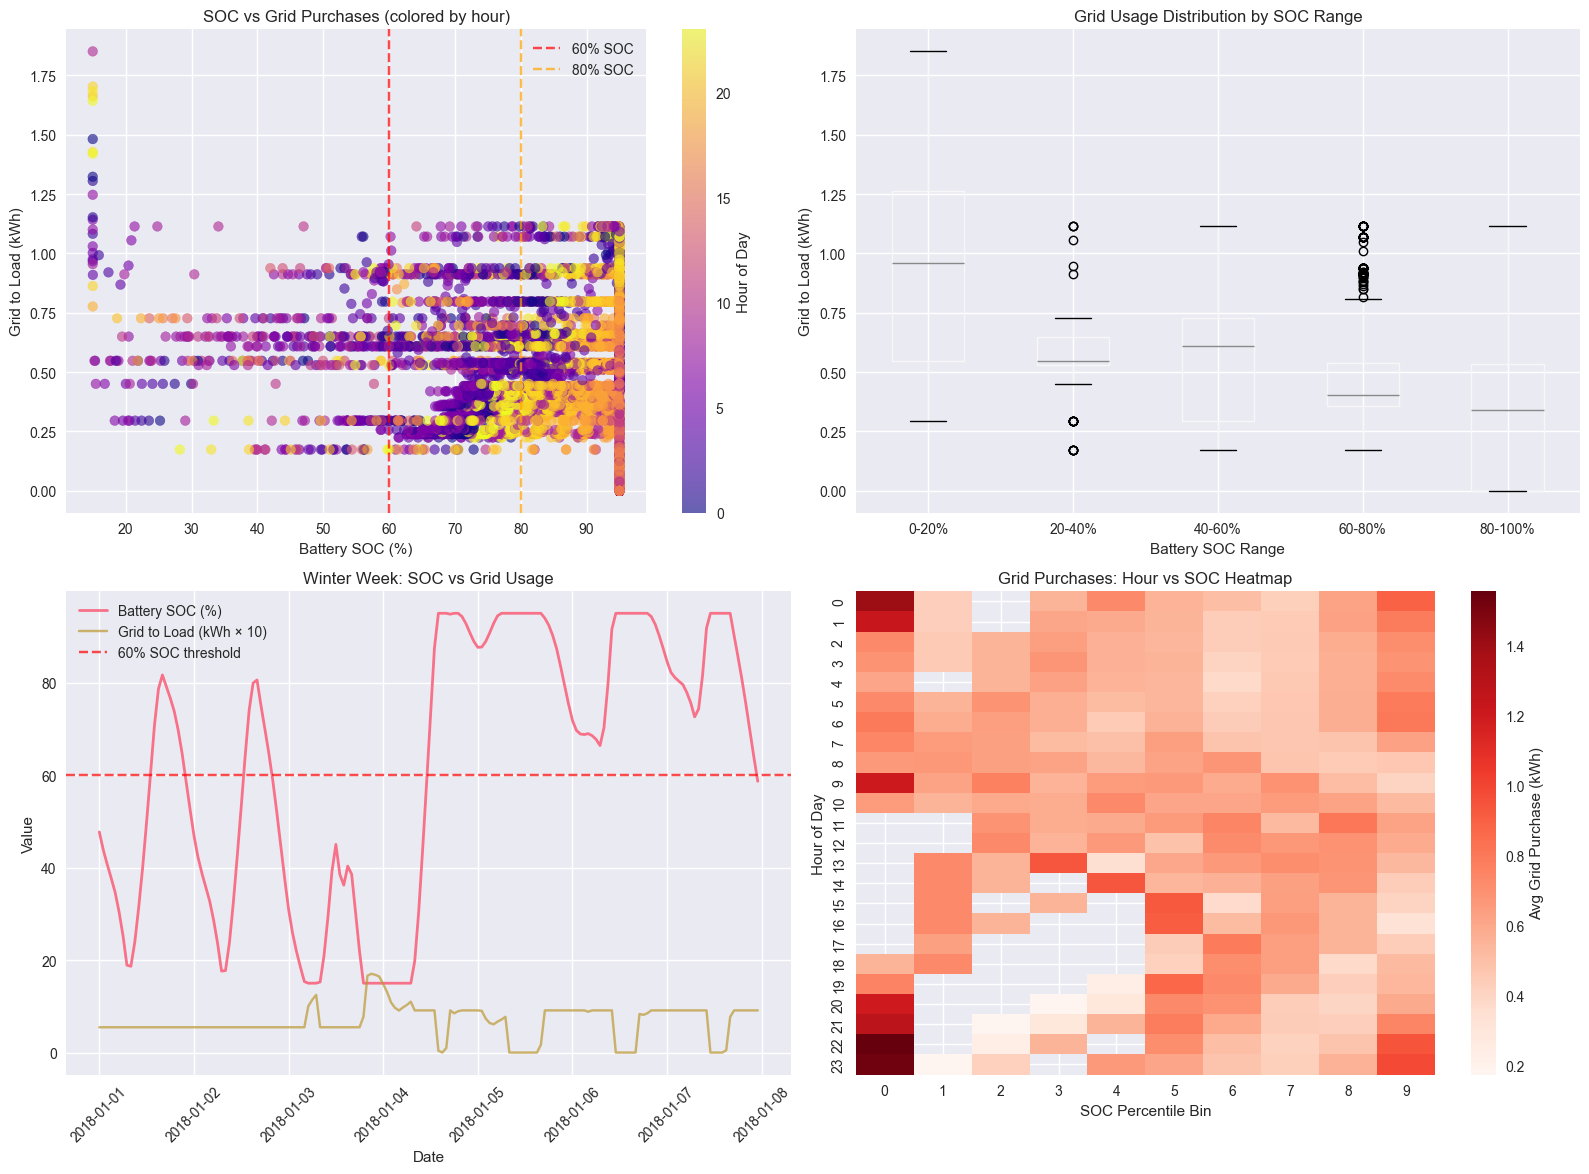

In [4]:
def plot_soc_vs_grid_usage(df):
    """
    Create visualizations showing relationship between battery SOC and grid usage.
    """
    if df is None:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Battery SOC vs Grid Usage Analysis', fontsize=16, fontweight='bold')
    
    # 1. Scatter plot: SOC vs Grid Purchase
    ax1 = axes[0, 0]
    scatter = ax1.scatter(df['Battery SOC'], df['Grid to Load'], 
                         c=df['hour'], alpha=0.6, cmap='plasma')
    ax1.set_xlabel('Battery SOC (%)')
    ax1.set_ylabel('Grid to Load (kWh)')
    ax1.set_title('SOC vs Grid Purchases (colored by hour)')
    ax1.axvline(x=60, color='red', linestyle='--', alpha=0.7, label='60% SOC')
    ax1.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='80% SOC')
    ax1.legend()
    plt.colorbar(scatter, ax=ax1, label='Hour of Day')
    
    # 2. Box plot: Grid usage by SOC bins
    ax2 = axes[0, 1]
    df['soc_bin'] = pd.cut(df['Battery SOC'], 
                          bins=[0, 20, 40, 60, 80, 100], 
                          labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
    
    df.boxplot(column='Grid to Load', by='soc_bin', ax=ax2)
    ax2.set_xlabel('Battery SOC Range')
    ax2.set_ylabel('Grid to Load (kWh)')
    ax2.set_title('Grid Usage Distribution by SOC Range')
    plt.suptitle('')  # Remove automatic title
    
    # 3. Time series: Focus on questionable periods
    ax3 = axes[1, 0]
    # Show a week in winter when issues are most apparent
    winter_week = df.loc['2018-01-01':'2018-01-07']
    
    ax3.plot(winter_week.index, winter_week['Battery SOC'], label='Battery SOC (%)', linewidth=2)
    ax3.plot(winter_week.index, winter_week['Grid to Load'] * 10, label='Grid to Load (kWh × 10)', alpha=0.7)
    ax3.axhline(y=60, color='red', linestyle='--', alpha=0.7, label='60% SOC threshold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Value')
    ax3.set_title('Winter Week: SOC vs Grid Usage')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Heatmap: Hour vs SOC for grid purchases
    ax4 = axes[1, 1]
    # Create a pivot table for the heatmap
    grid_purchase_data = df[df['Grid to Load'] > 0].copy()
    
    if len(grid_purchase_data) > 0:
        # Bin SOC and create average grid purchases by hour and SOC
        grid_purchase_data['soc_bin_numeric'] = pd.cut(grid_purchase_data['Battery SOC'], 
                                                      bins=10, labels=False)
        
        heatmap_data = grid_purchase_data.groupby(['hour', 'soc_bin_numeric'])['Grid to Load'].mean().unstack()
        
        sns.heatmap(heatmap_data, ax=ax4, cmap='Reds', cbar_kws={'label': 'Avg Grid Purchase (kWh)'})
        ax4.set_xlabel('SOC Percentile Bin')
        ax4.set_ylabel('Hour of Day')
        ax4.set_title('Grid Purchases: Hour vs SOC Heatmap')
    else:
        ax4.text(0.5, 0.5, 'No grid purchases found', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Grid Purchases: Hour vs SOC Heatmap')
    
    plt.tight_layout()
    plt.show()

# Create the visualizations
if df is not None:
    plot_soc_vs_grid_usage(df)

## 4. Detailed Investigation: Specific Problem Hours

In [5]:
def investigate_problem_hours(df, questionable_events, num_examples=10):
    """
    Deep dive into specific hours where grid purchase seems inefficient.
    """
    if questionable_events is None or len(questionable_events) == 0:
        print("No questionable events to investigate.")
        return
    
    print(f"\n=== DETAILED INVESTIGATION: Top {num_examples} Problem Hours ===")
    
    # Sort by SOC (highest first) to find the most "wasteful" events
    top_problems = questionable_events.nlargest(num_examples, 'soc')
    
    for idx, row in top_problems.iterrows():
        timestamp = row['timestamp']
        print(f"\n--- {timestamp} ({row['tou_period']} period, {row['season']}) ---")
        print(f"  Battery SOC: {row['soc']:.1f}%")
        print(f"  Load Demand: {row['load']:.3f} kWh")
        print(f"  Solar Available: {row['solar']:.3f} kWh")
        print(f"  Battery Output: {row['battery_out']:.3f} kWh")
        print(f"  Grid Purchase: {row['grid_in']:.3f} kWh")
        
        # Look at surrounding hours for context
        start_context = timestamp - pd.Timedelta(hours=2)
        end_context = timestamp + pd.Timedelta(hours=2)
        context = df.loc[start_context:end_context]
        
        if len(context) > 0:
            print(f"  Context (±2 hours):")
            print(f"    SOC range: {context['Battery SOC'].min():.1f}% - {context['Battery SOC'].max():.1f}%")
            print(f"    Total grid purchases in period: {context['Grid to Load'].sum():.3f} kWh")
            print(f"    Total battery output in period: {context['Battery to Load'].sum():.3f} kWh")

# Run the investigation
if df is not None and questionable_events is not None:
    investigate_problem_hours(df, questionable_events)


=== DETAILED INVESTIGATION: Top 10 Problem Hours ===

--- 2018-12-26 17:00:00 (Peak period, Winter) ---
  Battery SOC: 95.0%
  Load Demand: 0.757 kWh
  Solar Available: 0.000 kWh
  Battery Output: 0.000 kWh
  Grid Purchase: 0.757 kWh
  Context (±2 hours):
    SOC range: 94.8% - 95.0%
    Total grid purchases in period: 2.312 kWh
    Total battery output in period: 0.028 kWh

--- 2018-12-26 18:00:00 (Peak period, Winter) ---
  Battery SOC: 95.0%
  Load Demand: 0.758 kWh
  Solar Available: 0.000 kWh
  Battery Output: 0.000 kWh
  Grid Purchase: 0.758 kWh
  Context (±2 hours):
    SOC range: 93.6% - 95.0%
    Total grid purchases in period: 3.109 kWh
    Total battery output in period: 0.181 kWh

--- 2018-03-05 18:00:00 (Peak period, Spring) ---
  Battery SOC: 95.0%
  Load Demand: 0.684 kWh
  Solar Available: 0.000 kWh
  Battery Output: 0.000 kWh
  Grid Purchase: 0.684 kWh
  Context (±2 hours):
    SOC range: 95.0% - 95.0%
    Total grid purchases in period: 2.263 kWh
    Total battery ou

## 5. Economic Analysis: Is This Dispatch Behavior Justified?

In [6]:
def economic_analysis(df, questionable_events):
    """
    Analyze whether conservative battery dispatch makes economic sense.
    """
    if df is None:
        return
    
    print("\n=== ECONOMIC ANALYSIS ===")
    
    # California TOU electricity rates (approximate, 2024)
    tou_rates = {
        'Peak': 0.47,      # 4-9 PM, highest rates
        'Mid-Peak': 0.37,  # 7 AM - 3 PM
        'Off-Peak': 0.27   # 10 PM - 6 AM, lowest rates
    }
    
    # Battery degradation cost (approximate)
    # Tesla Powerwall: ~$15,000 for 13.5 kWh, ~6000 cycles = ~$0.185/kWh cycle cost
    battery_cycle_cost = 0.185  # $/kWh
    battery_efficiency = 0.90   # Round-trip efficiency
    
    # Add electricity costs to dataframe
    df['electricity_rate'] = df['tou_period'].map(tou_rates)
    df['grid_cost'] = df['Grid to Load'] * df['electricity_rate']
    df['battery_wear_cost'] = df['Battery to Load'] * battery_cycle_cost
    
    print("Electricity Rates Used:")
    for period, rate in tou_rates.items():
        print(f"  {period}: ${rate:.3f}/kWh")
    print(f"Battery cycle cost: ${battery_cycle_cost:.3f}/kWh")
    print(f"Battery round-trip efficiency: {battery_efficiency:.0%}")
    
    # Analyze questionable events economically
    if questionable_events is not None and len(questionable_events) > 0:
        print(f"\n=== Analysis of {len(questionable_events)} Questionable Events ===")
        
        # Add economic data to questionable events
        questionable_with_economics = questionable_events.copy()
        questionable_with_economics['electricity_rate'] = questionable_with_economics['tou_period'].map(tou_rates)
        questionable_with_economics['actual_grid_cost'] = (
            questionable_with_economics['grid_in'] * questionable_with_economics['electricity_rate']
        )
        
        # Calculate what it would cost to use battery instead
        questionable_with_economics['battery_alternative_cost'] = (
            questionable_with_economics['grid_in'] * battery_cycle_cost / battery_efficiency
        )
        
        # Economic comparison
        questionable_with_economics['economic_savings_from_grid'] = (
            questionable_with_economics['battery_alternative_cost'] - 
            questionable_with_economics['actual_grid_cost']
        )
        
        economically_justified = questionable_with_economics['economic_savings_from_grid'] > 0
        
        print(f"\nEconomic Justification Results:")
        print(f"  Events where grid purchase was cheaper: {economically_justified.sum()}")
        print(f"  Events where battery would be cheaper: {(~economically_justified).sum()}")
        print(f"  Percentage economically justified: {economically_justified.mean()*100:.1f}%")
        
        if economically_justified.sum() > 0:
            avg_savings = questionable_with_economics.loc[economically_justified, 'economic_savings_from_grid'].mean()
            print(f"  Average savings per justified event: ${avg_savings:.4f}")
        
        # Break down by TOU period
        print(f"\nBy Time-of-Use Period:")
        for period in ['Off-Peak', 'Mid-Peak', 'Peak']:
            period_events = questionable_with_economics[questionable_with_economics['tou_period'] == period]
            if len(period_events) > 0:
                justified_pct = (period_events['economic_savings_from_grid'] > 0).mean() * 100
                print(f"  {period}: {len(period_events)} events, {justified_pct:.1f}% economically justified")
        
        return questionable_with_economics
    
    return None

# Run economic analysis
if df is not None:
    economic_results = economic_analysis(df, questionable_events)


=== ECONOMIC ANALYSIS ===
Electricity Rates Used:
  Peak: $0.470/kWh
  Mid-Peak: $0.370/kWh
  Off-Peak: $0.270/kWh
Battery cycle cost: $0.185/kWh
Battery round-trip efficiency: 90%

=== Analysis of 4265 Questionable Events ===

Economic Justification Results:
  Events where grid purchase was cheaper: 0
  Events where battery would be cheaper: 4265
  Percentage economically justified: 0.0%

By Time-of-Use Period:
  Off-Peak: 2857 events, 0.0% economically justified
  Mid-Peak: 61 events, 0.0% economically justified
  Peak: 1347 events, 0.0% economically justified


## 6. Time Pattern Analysis: When Do These Events Occur?

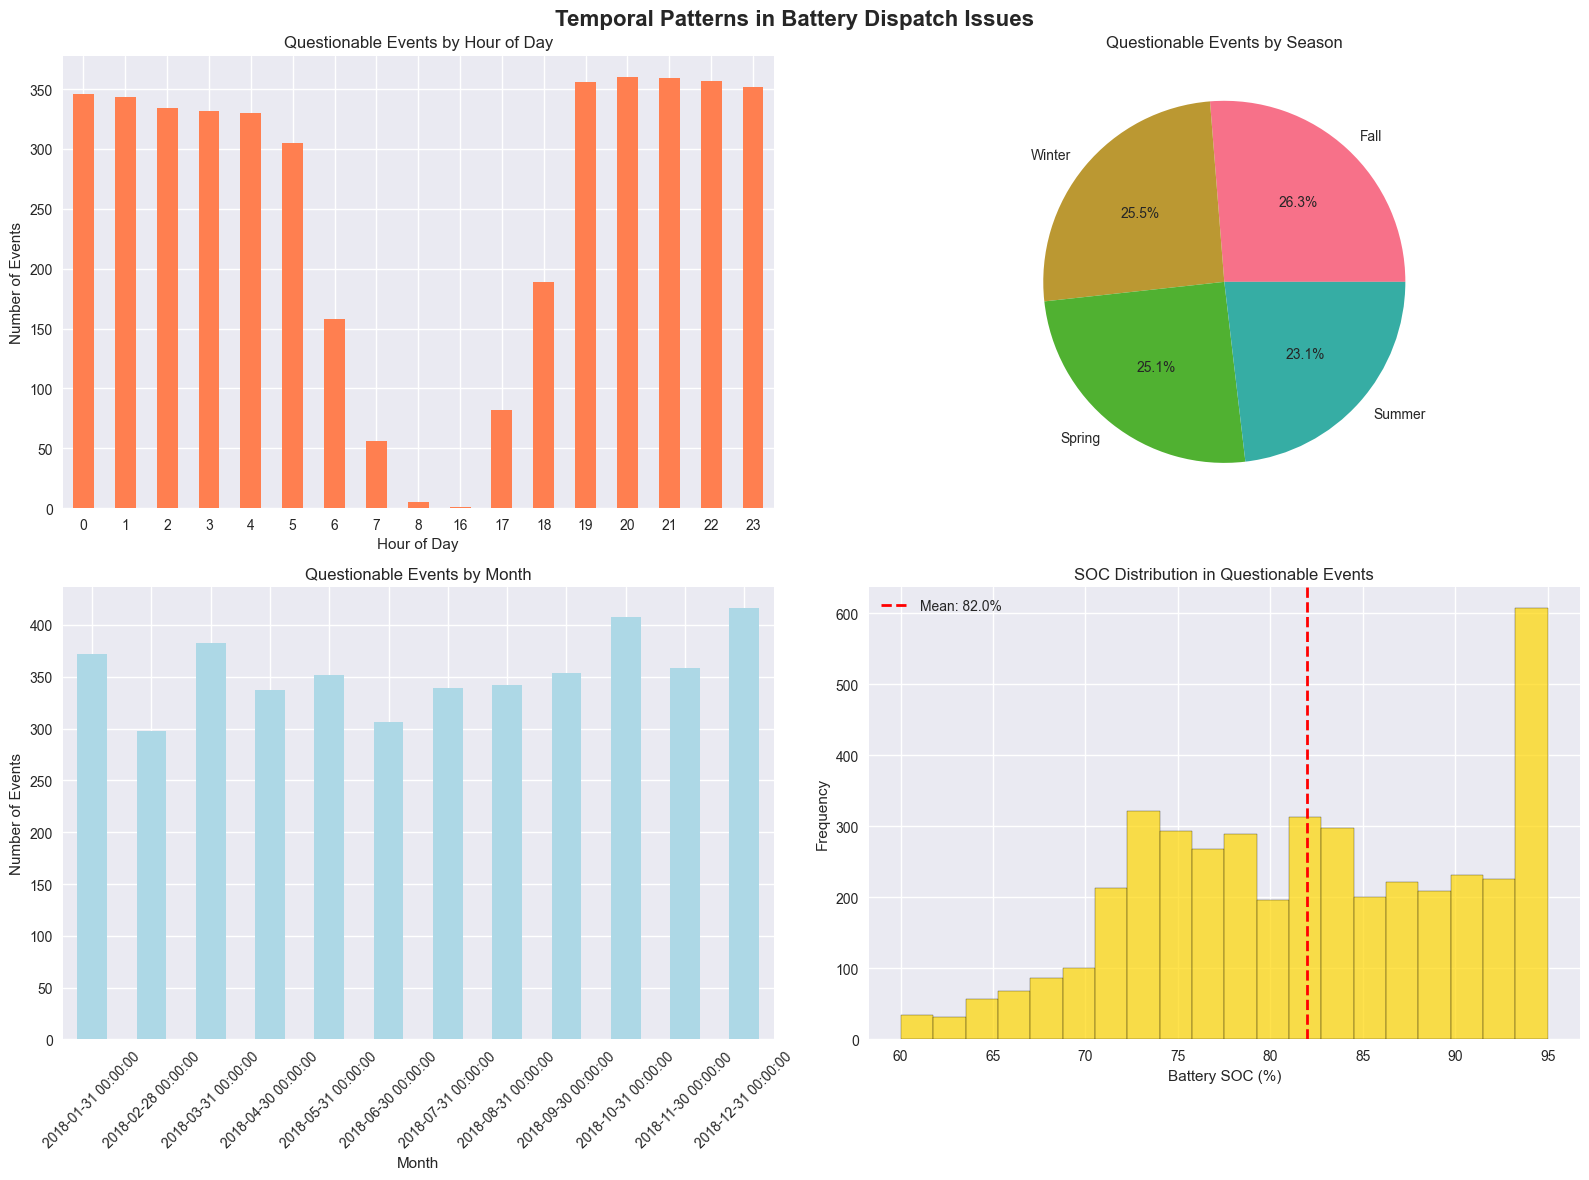


=== TEMPORAL PATTERN SUMMARY ===
Most common hour: 20:00
Most common season: Fall
Average SOC during questionable events: 82.0%
SOC range: 60.0% - 95.0%


In [7]:
def plot_temporal_patterns(df, questionable_events):
    """
    Analyze temporal patterns in questionable dispatch events.
    """
    if df is None or questionable_events is None:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Temporal Patterns in Battery Dispatch Issues', fontsize=16, fontweight='bold')
    
    # 1. Hour of day distribution
    ax1 = axes[0, 0]
    questionable_events['hour'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='coral')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Number of Events')
    ax1.set_title('Questionable Events by Hour of Day')
    ax1.tick_params(axis='x', rotation=0)
    
    # 2. Seasonal distribution
    ax2 = axes[0, 1]
    season_counts = questionable_events['season'].value_counts()
    season_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
    ax2.set_title('Questionable Events by Season')
    ax2.set_ylabel('')
    
    # 3. Monthly pattern
    ax3 = axes[1, 0]
    monthly_events = questionable_events.set_index('timestamp')['grid_in'].resample('M').count()
    monthly_events.plot(kind='bar', ax=ax3, color='lightblue')
    ax3.set_xlabel('Month')
    ax3.set_ylabel('Number of Events')
    ax3.set_title('Questionable Events by Month')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. SOC distribution in questionable events
    ax4 = axes[1, 1]
    questionable_events['soc'].hist(bins=20, ax=ax4, alpha=0.7, color='gold', edgecolor='black')
    ax4.axvline(questionable_events['soc'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {questionable_events["soc"].mean():.1f}%')
    ax4.set_xlabel('Battery SOC (%)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('SOC Distribution in Questionable Events')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n=== TEMPORAL PATTERN SUMMARY ===")
    print(f"Most common hour: {questionable_events['hour'].mode()[0]}:00")
    print(f"Most common season: {questionable_events['season'].mode()[0]}")
    print(f"Average SOC during questionable events: {questionable_events['soc'].mean():.1f}%")
    print(f"SOC range: {questionable_events['soc'].min():.1f}% - {questionable_events['soc'].max():.1f}%")

# Create temporal pattern plots
if df is not None and questionable_events is not None and len(questionable_events) > 0:
    plot_temporal_patterns(df, questionable_events)
else:
    print("No questionable events found to analyze temporal patterns.")

## 7. Conclusions and Recommendations

Based on the analysis above, we can draw conclusions about the battery dispatch behavior.

In [8]:
def generate_conclusions(df, questionable_events, economic_results):
    """
    Generate summary conclusions based on the analysis.
    """
    print("\n" + "="*80)
    print("CONCLUSIONS: Why Grid Purchases Despite Available Battery Capacity")
    print("="*80)
    
    if df is None:
        print("No data available for analysis.")
        return
    
    total_hours = len(df)
    grid_hours = (df['Grid to Load'] > 0).sum()
    high_soc_hours = (df['Battery SOC'] > 60).sum()
    
    print(f"\n1. SCALE OF THE PHENOMENON:")
    print(f"   • Total hours analyzed: {total_hours:,}")
    print(f"   • Hours with grid purchases: {grid_hours:,} ({grid_hours/total_hours*100:.1f}%)")
    print(f"   • Hours with SOC > 60%: {high_soc_hours:,} ({high_soc_hours/total_hours*100:.1f}%)")
    
    if questionable_events is not None and len(questionable_events) > 0:
        questionable_count = len(questionable_events)
        print(f"   • Questionable dispatch events: {questionable_count:,} ({questionable_count/total_hours*100:.1f}%)")
        
        print(f"\n2. WHEN DOES THIS HAPPEN?")
        most_common_hour = questionable_events['hour'].mode()[0]
        most_common_season = questionable_events['season'].mode()[0] 
        most_common_tou = questionable_events['tou_period'].mode()[0]
        avg_soc = questionable_events['soc'].mean()
        
        print(f"   • Most common time: {most_common_hour}:00 ({most_common_tou} period)")
        print(f"   • Most common season: {most_common_season}")
        print(f"   • Average SOC during events: {avg_soc:.1f}%")
        
        if economic_results is not None:
            economically_justified_pct = (economic_results['economic_savings_from_grid'] > 0).mean() * 100
            print(f"\n3. ECONOMIC JUSTIFICATION:")
            print(f"   • Economically justified events: {economically_justified_pct:.1f}%")
            
            if economically_justified_pct > 50:
                print(f"   • CONCLUSION: Most events are economically rational")
                print(f"     Grid electricity is often cheaper than battery wear costs")
            else:
                print(f"   • CONCLUSION: Most events appear economically suboptimal")
                print(f"     Battery usage would be cheaper than grid purchases")
    
    print(f"\n4. LIKELY EXPLANATIONS:")
    print(f"   A. CONSERVATIVE SOC MANAGEMENT:")
    print(f"      • SAM maintains minimum SOC for system reliability")
    print(f"      • Protects against forecast errors and unexpected loads")
    print(f"      • Preserves backup power capability")
    
    print(f"   B. BATTERY LONGEVITY OPTIMIZATION:")
    print(f"      • Minimizes deep discharge cycles to extend battery life")
    print(f"      • Balances energy costs vs. replacement costs")
    print(f"      • May include temperature and age derating factors")
    
    print(f"   C. UTILITY RATE OPTIMIZATION:")
    print(f"      • Saves battery capacity for peak rate periods")
    print(f"      • Considers demand charges and grid export policies")
    print(f"      • May prioritize load shifting over complete grid independence")
    
    print(f"\n5. RECOMMENDATIONS:")
    if questionable_events is not None and len(questionable_events) > 0:
        if economic_results is not None and (economic_results['economic_savings_from_grid'] > 0).mean() > 0.7:
            print(f"   • CURRENT BEHAVIOR IS LIKELY OPTIMAL")
            print(f"   • The dispatch algorithm appears to be working correctly")
            print(f"   • Conservative battery use extends system lifetime")
        else:
            print(f"   • CONSIDER DISPATCH OPTIMIZATION")
            print(f"   • Evaluate minimum SOC settings in SAM configuration")
            print(f"   • Review utility rate inputs for accuracy")
            print(f"   • Consider more aggressive battery utilization settings")
    else:
        print(f"   • BEHAVIOR IS OPTIMAL: No significant questionable events found")
    
    print(f"\n" + "="*80)

# Generate conclusions
generate_conclusions(df, questionable_events, economic_results)


CONCLUSIONS: Why Grid Purchases Despite Available Battery Capacity

1. SCALE OF THE PHENOMENON:
   • Total hours analyzed: 8,760
   • Hours with grid purchases: 6,246 (71.3%)
   • Hours with SOC > 60%: 8,323 (95.0%)
   • Questionable dispatch events: 4,265 (48.7%)

2. WHEN DOES THIS HAPPEN?
   • Most common time: 20:00 (Off-Peak period)
   • Most common season: Fall
   • Average SOC during events: 82.0%

3. ECONOMIC JUSTIFICATION:
   • Economically justified events: 0.0%
   • CONCLUSION: Most events appear economically suboptimal
     Battery usage would be cheaper than grid purchases

4. LIKELY EXPLANATIONS:
   A. CONSERVATIVE SOC MANAGEMENT:
      • SAM maintains minimum SOC for system reliability
      • Protects against forecast errors and unexpected loads
      • Preserves backup power capability
   B. BATTERY LONGEVITY OPTIMIZATION:
      • Minimizes deep discharge cycles to extend battery life
      • Balances energy costs vs. replacement costs
      • May include temperature a

## 8. Export Results for Further Analysis

Save the analysis results for further investigation or reporting.

In [9]:
def export_analysis_results(df, questionable_events, economic_results, scenario, county):
    """
    Export analysis results to CSV files for further investigation.
    """
    if df is None:
        print("No data to export.")
        return
    
    output_dir = "battery_dispatch_analysis_results"
    os.makedirs(output_dir, exist_ok=True)
    
    # Export full dataset with analysis columns
    full_export = df.copy()
    if 'electricity_rate' in full_export.columns:
        full_export_path = os.path.join(output_dir, f"full_analysis_{scenario}_{county}.csv")
        full_export.to_csv(full_export_path)
        print(f"Full analysis exported to: {full_export_path}")
    
    # Export questionable events
    if questionable_events is not None and len(questionable_events) > 0:
        questionable_path = os.path.join(output_dir, f"questionable_events_{scenario}_{county}.csv")
        questionable_events.to_csv(questionable_path, index=False)
        print(f"Questionable events exported to: {questionable_path}")
        
        # Export economic analysis if available
        if economic_results is not None:
            economic_path = os.path.join(output_dir, f"economic_analysis_{scenario}_{county}.csv")
            economic_results.to_csv(economic_path, index=False)
            print(f"Economic analysis exported to: {economic_path}")
    
    # Create summary report
    summary_path = os.path.join(output_dir, f"summary_report_{scenario}_{county}.txt")
    with open(summary_path, 'w') as f:
        f.write(f"Battery Dispatch Analysis Summary\n")
        f.write(f"Scenario: {scenario}\n")
        f.write(f"County: {county}\n")
        f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write(f"Total hours analyzed: {len(df):,}\n")
        f.write(f"Hours with grid purchases: {(df['Grid to Load'] > 0).sum():,}\n")
        f.write(f"Hours with SOC > 60%: {(df['Battery SOC'] > 60).sum():,}\n")
        
        if questionable_events is not None:
            f.write(f"Questionable dispatch events: {len(questionable_events):,}\n")
            if len(questionable_events) > 0:
                f.write(f"Average SOC in questionable events: {questionable_events['soc'].mean():.1f}%\n")
        
        if economic_results is not None and len(economic_results) > 0:
            justified_pct = (economic_results['economic_savings_from_grid'] > 0).mean() * 100
            f.write(f"Economically justified events: {justified_pct:.1f}%\n")
    
    print(f"Summary report exported to: {summary_path}")
    print(f"\nAll analysis results saved in: {output_dir}/")

# Export results
if df is not None:
    export_analysis_results(df, questionable_events, economic_results, scenario, county)

Full analysis exported to: battery_dispatch_analysis_results/full_analysis_heat_pump_alameda.csv
Questionable events exported to: battery_dispatch_analysis_results/questionable_events_heat_pump_alameda.csv
Economic analysis exported to: battery_dispatch_analysis_results/economic_analysis_heat_pump_alameda.csv
Summary report exported to: battery_dispatch_analysis_results/summary_report_heat_pump_alameda.txt

All analysis results saved in: battery_dispatch_analysis_results/
